## 📜 Análise de sinais sonoros em Pyhon
por Iury Coelho

Este notebook tem o proposito de analisar, através da programação em python e amostras sonoras,  harmônicos e  resultados computacionais relacionados com o roteiro de estudo.

#### Conteúdo

* [1ª Amostra](#1_Amostra)
* [2ª Amostra](#2_Amostra)
* [3ª Amostra](#3_Amostra)


In [1]:
import numpy as np
from IPython.display import Audio, display, HTML
from ipywidgets import interact

import matplotlib.pyplot as plt
from scipy.io import wavfile
import requests
from io import BytesIO

In [2]:
def fourierSeries(period, N):
    """Calculate the Fourier series coefficients up to the Nth harmonic"""
    result = []
    T = len(period)
    t = np.arange(T)
    for n in range(N+1):
        an = 2/T*(period * np.cos(2*np.pi*n*t/T)).sum()
        bn = 2/T*(period * np.sin(2*np.pi*n*t/T)).sum()
        result.append((an, bn))
    return np.array(result)

In [3]:
def reconstruct(P, anbn):
    """Sum up sines and cosines according to the coefficients to 
    produce a reconstruction of the original waveform"""
    result = 0
    t = np.arange(P)
    for n, (a, b) in enumerate(anbn):
        if n == 0:
            a = a/2
        result = result + a*np.cos(2*np.pi*n*t/P) + b * np.sin(2*np.pi*n*t/P)
    return result

As amostras de áudio são **baixadas por URL** de uma fonte estável (pyroomacoustics / LCAV). O carregamento tem *fallback* sintético, então o notebook roda do zero mesmo sem internet.

In [4]:
def loadSound(url, fallback_f0=220, fallback_fs=8000, fallback_dur=2.0, timeout=20):
    # Baixa um .wav por URL e normaliza para [-1, 1] (mono). Se falhar, gera um
    # tom harmonico sintetico para o notebook rodar do zero (ex.: no CI).
    try:
        R = requests.get(url, timeout=timeout, headers={"User-Agent": "Mozilla/5.0"})
        R.raise_for_status()
        rate, data = wavfile.read(BytesIO(R.content))
        data = np.asarray(data, dtype=float)
        if data.ndim > 1:
            data = data[:, 0]
        return data / (np.abs(data).max() or 1.0), int(rate)
    except Exception as e:
        print(f"[aviso] download falhou ({type(e).__name__}); usando tom sintetico.")
        fs = fallback_fs
        t = np.linspace(0, fallback_dur, int(fs * fallback_dur), endpoint=False)
        s = sum((1.0 / k) * np.sin(2 * np.pi * fallback_f0 * k * t) for k in range(1, 10))
        return s / np.abs(s).max(), fs

BASE = "https://raw.githubusercontent.com/LCAV/pyroomacoustics/master/examples/input_samples/"
SONS = [
    ("Canto (rico em harmônicos)", BASE + "singing_8000.wav"),
    ("Voz masculina", BASE + "cmu_arctic_us_aew_a0001.wav"),
    ("Voz feminina", BASE + "cmu_arctic_us_axb_a0004.wav"),
]

def mostrar_som(nome, url):
    x, fs = loadSound(url)
    t = np.arange(len(x)) / fs
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3))
    a1.plot(t, x); a1.set_title(nome + " — forma de onda")
    a1.set_xlabel("t [s]"); a1.grid(alpha=.3)
    meio = len(x) // 2
    jan = slice(meio, meio + int(0.05 * fs))   # zoom de 50 ms no meio
    a2.plot(t[jan], x[jan]); a2.set_title("zoom (50 ms) — periodicidade")
    a2.set_xlabel("t [s]"); a2.grid(alpha=.3)
    plt.tight_layout(); plt.show()
    display(Audio(x, rate=fs))
    return x, fs

### 1ª amostra — canto

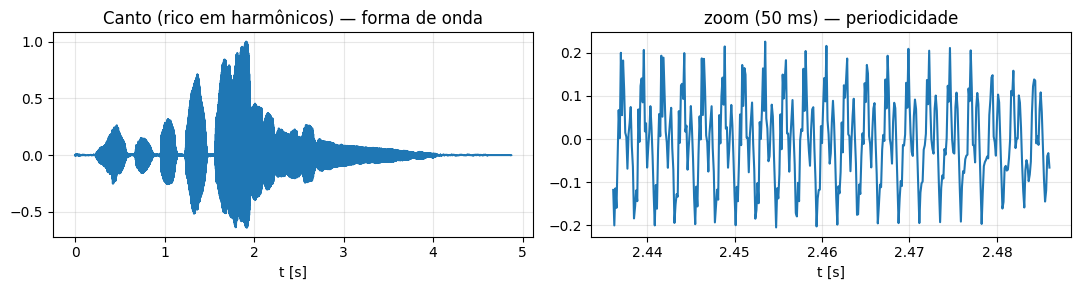

In [5]:
x1, fs1 = mostrar_som(*SONS[0])

### 2ª amostra — voz masculina

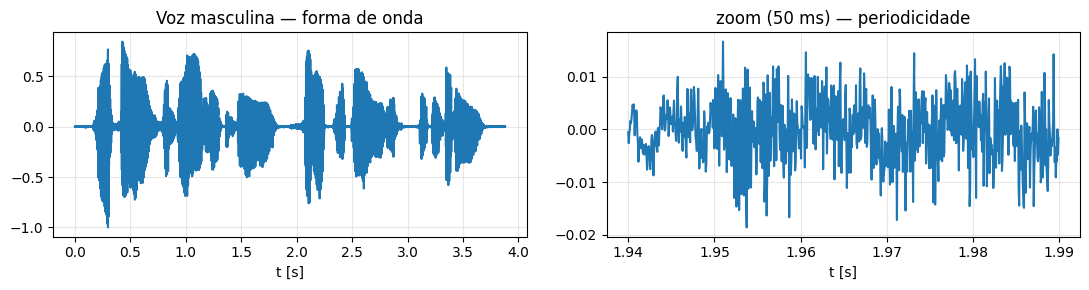

In [6]:
x2, fs2 = mostrar_som(*SONS[1])

### 3ª amostra — voz feminina

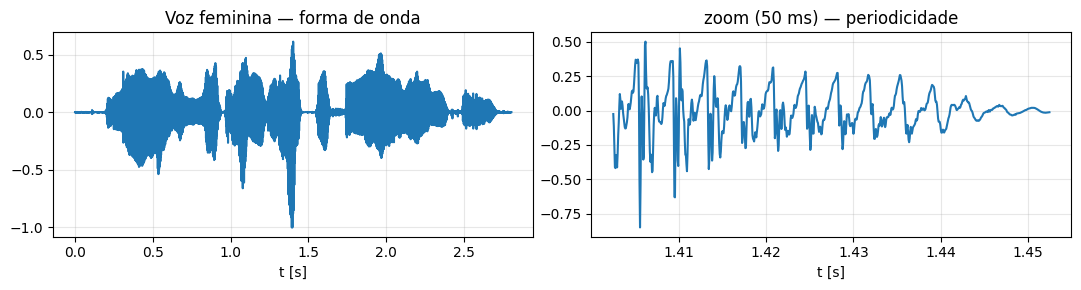

In [7]:
x3, fs3 = mostrar_som(*SONS[2])

## Análise espectral — os harmônicos

A Transformada de Fourier revela o conteúdo harmônico do som. No canto, os picos aparecem em múltiplos (harmônicos) da frequência fundamental.

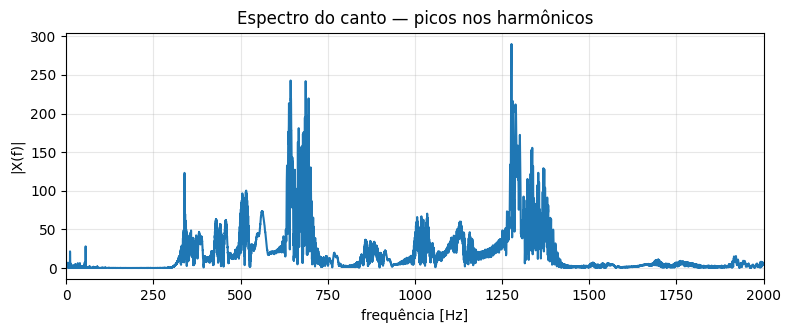

In [8]:
X = np.abs(np.fft.rfft(x1))
f = np.fft.rfftfreq(len(x1), 1 / fs1)
plt.figure(figsize=(9, 3.2))
plt.plot(f, X)
plt.xlim(0, 2000)
plt.grid(alpha=.3); plt.xlabel("frequência [Hz]"); plt.ylabel("|X(f)|")
plt.title("Espectro do canto — picos nos harmônicos")
plt.show()